### Final Project Code Version 6

Minimum X2: 16.13617717007719, Reduced X2: 0.08149584429331914
Parameters: A: -0.12474541267007726, B: 0.024960726926451345, C: 1.8999708547918457, l: 0.32520461990480687, δ: 0.09970632695927978
Minimum X2: 13.824750178193947, Reduced X2: 0.06982197059693912
Parameters: A: -0.12473160062868703, B: 0.02495811679721262, C: 1.899971460500862, l: 0.3248775530329163, δ: 0.09959789295599543
Minimum X2: 24.87262977004928, Reduced X2: 0.12561934227297616
Parameters: A: -0.12471902679745324, B: 0.024959313388687, C: 1.8999724813507677, l: 0.32480973515521294, δ: 0.09685053154571815
Correlation Coefficient: 0.9232674642498765


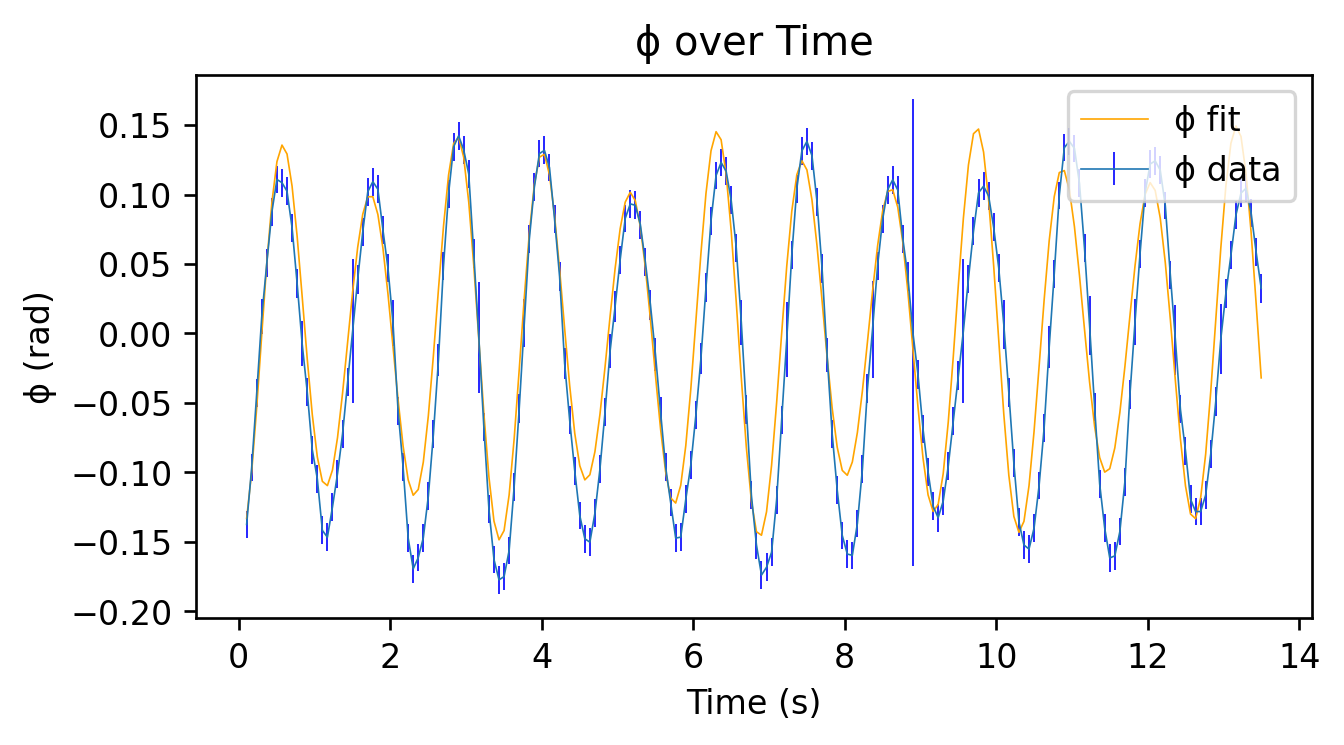

In [177]:
from numpy import array,append,ones_like,sqrt,linspace,arange,cos,sin,dot,arctan,e,argmax
import matplotlib.pyplot as plt

# Importing data
x = array([])
y = array([])
t = array([])

with open('Final Project Video Analysis 161101.csv') as file:
    lines = file.readlines()
    count = 1
    for line in lines:
        if count != 1:
            numbers = line.split(',')
            x = append(x, float(numbers[2]))
            y = append(y, float(numbers[5]))
            t = append(t,float(numbers[0]))
        count += 1
            
xerr = ones_like(x) * 0.01

h = 0.483
herr = 0.001
yerr = ones_like(y) * 0.005      
y1 = h - y
y1err = herr**2 + yerr**2

# Calculating phi and 
phi = arctan(x/y1)
phierr = sqrt((xerr**2 * (y1/(y1+x**2))**2) + (y1err**2 * (-x/x**2 + y1**2)**2))
index = argmax(phierr)


# Creating a fit line with the parameters
def phifit(A,B,C,l,δ):
    g = 9.8
    fit = (A - B*cos(C*t))*cos(sqrt(g/l)*t - δ)
    return fit

def χ2(phi,phifit,phierr):
    return sum(((phi-phifit)**2)/abs(phifit))

def deriv(parameter,A,B,C,l,δ,Δ):
    f = 0.125
    if parameter == 'A':
        fit1 = phifit(A + (f*Δ),B,C,l,δ)
    elif parameter == 'B':
        fit1 = phifit(A,B + (f*Δ),C,l,δ)
    elif parameter == 'C':
        fit1 = phifit(A,B,C + (f*Δ),l,δ)
    elif parameter == 'l':
        fit1 = phifit(A,B,C,l + (f*Δ),δ)
    else:
        fit1 = phifit(A,B,C,l,δ + (f*Δ)) 
    fit2 = phifit(A,B,C,l,δ)
    deriv = (χ2(phi,fit1,phierr) - χ2(phi,fit2,phierr))/(f*Δ)
    return deriv
   
step = 0.0001
ΔA = 0.001
ΔB = 0.001
ΔC = 0.001
Δl = 0.00001    
Δδ = 0.001  

A = -0.125
B = 0.025
C = 1.9
l = 0.26
δ = 0.1

fit = phifit(A,B,C,l,δ)
oldgrad = 100000000000
diff = 1

Aarray = array([])
Barray = array([])
Carray = array([])
larray = array([])
δarray = array([])
X2 = array([])

while diff > 1e-30:
    A += step*ΔA*deriv('A',A,B,C,l,δ,ΔA)
    B += step*ΔB*deriv('B',A,B,C,l,δ,ΔB)
    C += step*ΔC*deriv('C',A,B,C,l,δ,ΔC)
    l += step*Δl*deriv('l',A,B,C,l,δ,Δl)
    δ += step*Δδ*deriv('δ',A,B,C,l,δ,Δδ)
    fit = phifit(A,B,C,l,δ)
    newX2 = χ2(phi,fit,phierr)
    grad = sqrt((deriv('A',A,B,C,l,δ,ΔA))**2 + (deriv('B',A,B,C,l,δ,ΔB))**2 + (deriv('C',A,B,C,l,δ,ΔC))**2 + (deriv('l',A,B,C,l,δ,Δl))**2 + (deriv('δ',A,B,C,l,δ,Δδ))**2)
    diff = oldgrad - grad
    oldgrad = grad
    Aarray = append(Aarray,A)
    Barray = append(Barray,B)
    Carray = append(Carray,C)
    larray = append(larray,l)
    δarray = append(δarray,δ)
    X2 = append(X2,newX2)
    print(f'Minimum X2: {newX2}, Reduced X2: {newX2/(202-4)}')
    print(f'Parameters: A: {A}, B: {B}, C: {C}, l: {l}, δ: {δ}')

# Calculating numerator and denominator for r formula
num = dot(phi,fit)
den = sqrt(sum(phi**2)) * sqrt(sum(fit**2))

# Calculating r
r = num/den

print(f'Correlation Coefficient: {r}')

plt.figure(figsize=(6,3),dpi=240)
plt.title('ϕ over Time')
plt.xlabel('Time (s)')
plt.ylabel('ϕ (rad)')
plt.errorbar(t,phi,phierr,ecolor='blue',linewidth=0.5,label='ϕ data')
plt.plot(t,fit,'orange',linewidth=0.5,label='ϕ fit')
plt.legend(loc='upper right')
plt.show()

In [157]:
from numpy.linalg import det
from numpy import argmin

parameters = ['A','B','C','l','δ']

for i in parameters:
    if i == 'A':
        VarArray = Aarray
    elif i == 'B':
        VarArray = Barray
    elif i == 'C':
        VarArray = Carray
    elif i == 'l':
        VarArray = larray
    else:
        VarArray = δarray
        
    # Calculating parabola coefficients from last three points
    A1 = (VarArray[-3]**2)
    A2 = (VarArray[-2]**2)
    A3 = (VarArray[-1]**2)
    B1 = VarArray[-3]
    B2 = VarArray[-2]
    B3 = VarArray[-1]
    C1 = X2[-3]
    C2 = X2[-2]
    C3 = X2[-1]

    D1 = array([[A1,B1,1],[A2,B2,1],[A3,B3,1]])
    D2 = array([[C1,B1,1],[C2,B2,1],[C3,B3,1]])
    D3 = array([[A1,C1,1],[A2,C2,1],[A3,C3,1]])
    D4 = array([[A1,B1,C1],[A2,B2,C2],[A3,B3,C3]])

    D = det(D1)
    Da = det(D2)
    Db = det(D3)
    Dc = det(D4)

    a = Da/D
    b = Db/D
    c = Dc/D
    
    if i == 'A':
        top = -0.12
        bottom = -0.125
    elif i == 'B':
        top = 0.26
        bottom = 0.24
    elif i == 'C':
        top = 2.1
        bottom = 1.8
    elif i == 'l':
        top = 0.326
        bottom = 0.324
    else:
        top = 0.1
        bottom = 0.09

    # Creating a smaller array of variable (Gamma2 in this case) values to use for the parabola
    Varval = linspace(bottom,top,2000000)
    # Calculating parabola values
    parabola = (a*Varval**2) + (b*Varval) + c
    
    # Finding the minimum chi squared value and the corresponding variable value from the parabola
    minX2 = min(parabola)
    x = argmin(parabola)
    finalVar = float(Varval[x])

    # Calculating error in the variable (Gamma2)
    σVar = ((top-bottom)/2000000)*sqrt(2*((X2[-3]**2 - (2*(X2[-2]**2)) + X2[-1]**2)**-1))
    
    if i == 'A':
        print(f'Minimum X2: {minX2:.3f}, Reduced X2: {minX2/(202-4):.3f} A: {finalVar:.7f}, A error: {σVar}')
    elif i == 'B':
        print(f'Minimum X2: {minX2:.3f}, Reduced X2: {minX2/(202-4):.3f} B: {finalVar:.7f}, B error: {σVar}')
    elif i == 'C':
        print(f'Minimum X2: {minX2:.3f}, Reduced X2: {minX2/(202-4):.3f} C: {finalVar:.7f}, C error: {σVar}')
    elif i == 'l':
        print(f'Minimum X2: {minX2:.3f}, Reduced X2: {minX2/(202-4):.3f} l: {finalVar:.7f}, l error: {σVar}')
    else:
        print(f'Minimum X2: {minX2:.3f}, Reduced X2: {minX2/(202-4):.3f} δ: {finalVar:.7f}, δ error: {σVar}')

Minimum X2: 12.913, Reduced X2: 0.065 A: -0.1247364, A error: 1.5862604239486883e-10
Minimum X2: -326227415001.604, Reduced X2: -1647613207.079 B: 0.2600000, B error: 6.345041695794753e-10
Minimum X2: 10065.312, Reduced X2: 50.835 C: 1.8999713, C error: 9.517562543692124e-09
Minimum X2: 3.440, Reduced X2: 0.017 l: 0.3250329, l error: 6.345041695794753e-11
Minimum X2: 2.151, Reduced X2: 0.011 δ: 0.0984508, δ error: 3.1725208478973767e-10


Minimum X2: 58.65799328341514, Reduced X2: 0.5865799328341513
Parameters: A: 0.03498780399121954 B: 0.0010001763654544312, C: 0.02999999987082104, β: 4.257483518125924e-05, δ: -0.5009457392223913
Minimum X2: 51.38608554276378, Reduced X2: 0.5138608554276378
Parameters: A: 0.03499651973495577 B: 0.0010003250240737539, C: 0.029999999761126404, β: 4.475195869362097e-05, δ: -0.4997998923352166
Minimum X2: 155.48312905071825, Reduced X2: 1.5548312905071824
Parameters: A: 0.03499089406553408 B: 0.001000452630426603, C: 0.029999999646623417, β: 4.677420661241286e-05, δ: -0.5002681932282292
Correlation Coefficient: 0.17456387407419227


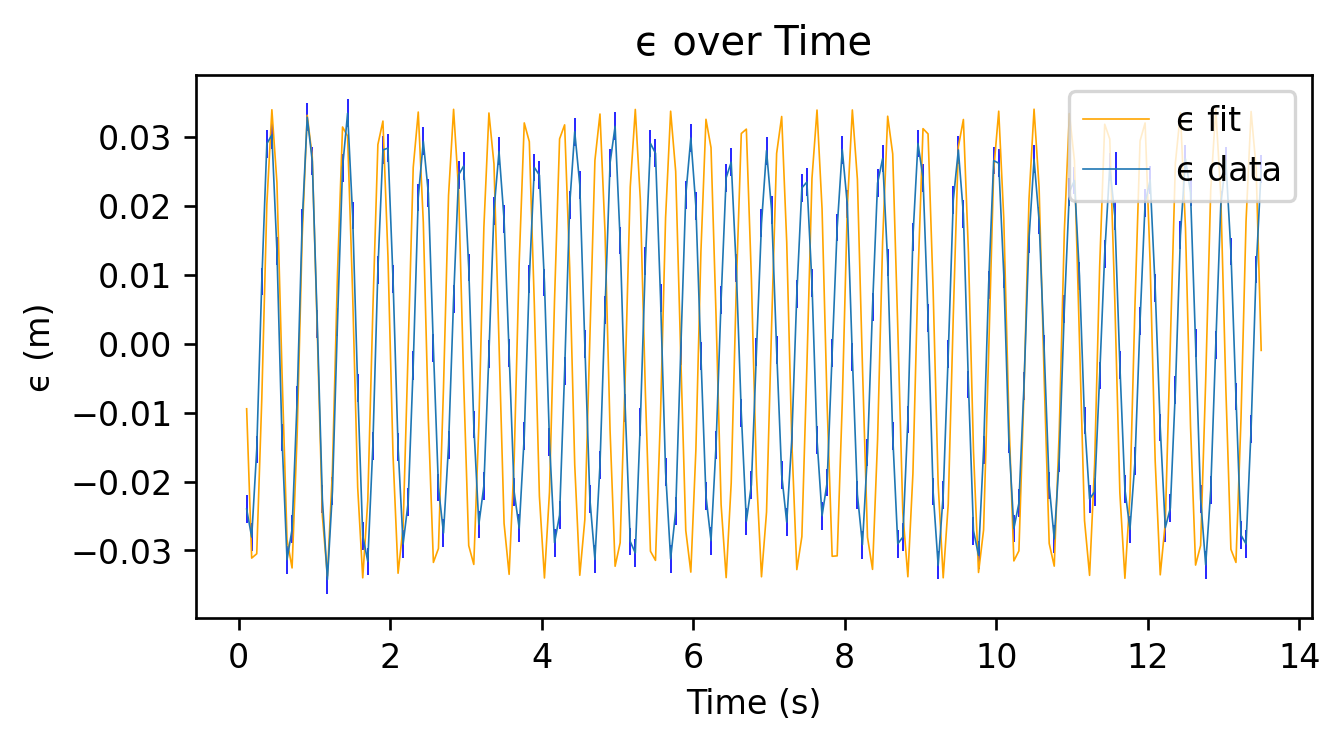

In [179]:
l = 0.26
lerr = 0.002
h = 0.483
herr = 0.001
yerr = ones_like(y) * 0.005      
y1 = h - y
y1err = herr**2 + yerr**2

r = y1/cos(phi)
ϵ = r - l
ϵerr = sqrt(lerr**2 + (y1err**2 * (1/cos(phi))**2) + (phierr**2 * ((y*sin(phi))/(cos(phi))**2)**2))

def ϵfit(A,B,C,β,δ):
    return (A - B*cos(C*t))*cos(sqrt(k/m)*t - δ)*(e**(-β*t))

def χ2(ϵ,ϵfit,ϵerr):
    return sum(((ϵ-ϵfit)**2)/(abs(ϵfit)))

def deriv(parameter,A,B,C,β,δ,Δ):
    f = 0.125
    if parameter == 'A':
        fit1 = ϵfit(A + (f*Δ),B,C,β,δ)
    if parameter == 'B':
        fit1 = ϵfit(A,B + (f*Δ),C,β,δ)
    elif parameter == 'C':
        fit1 = ϵfit(A,B,C + (f*Δ),β,δ)
    elif parameter == 'β':
        fit1 = ϵfit(A,B,C,β + (f*Δ),δ)
    else:
        fit1 = ϵfit(A,B,C,β,δ + (f*Δ))
    fit2 = ϵfit(A,B,C,β,δ)
    deriv = (χ2(ϵ,fit1,ϵerr) - χ2(ϵ,fit2,ϵerr))/(f*Δ)
    return deriv
   
step = 0.00001
ΔA = 0.00001
ΔB = 0.00001
ΔC = 0.00001  
ΔD = 0.0001
Δβ = 0.001
Δδ = 0.001

k = 172
m = 1

A = 0.035
B = 0.001
C = 0.03
β = 0.00004
δ = -0.5

fit = ϵfit(A,B,C,β,δ)
oldgrad = 100000000000
diff = 1

Aarray = array([])
Barray = array([])
Carray = array([])
βarray = array([])
δarray = array([])
X2 = array([])

while diff > 1e-6:
    A += step*ΔA*deriv('A',A,B,C,β,δ,ΔA)
    B += step*ΔB*deriv('B',A,B,C,β,δ,ΔB)
    C += step*ΔC*deriv('C',A,B,C,β,δ,ΔC)
    β += step*Δβ*deriv('β',A,B,C,β,δ,Δβ)
    δ += step*Δδ*deriv('δ',A,B,C,β,δ,Δδ)
    fit = ϵfit(A,B,C,β,δ)
    newX2 = χ2(ϵ,fit,ϵerr)
    grad = sqrt((deriv('A',A,B,C,β,δ,ΔA))**2 + (deriv('B',A,B,C,β,δ,ΔB))**2 + (deriv('C',A,B,C,β,δ,ΔC))**2 + (deriv('β',A,B,C,β,δ,Δβ))**2 + (deriv('δ',A,B,C,β,δ,Δδ))**2)
    diff = oldgrad - grad
    oldgrad = grad
    Aarray = append(Aarray,A)
    Barray = append(Barray,B)
    Carray = append(Carray,C)
    βarray = append(βarray,β)
    δarray = append(δarray,δ)
    X2 = append(X2,newX2)
    print(f'Minimum X2: {newX2}, Reduced X2: {newX2/100}')
    print(f'Parameters: A: {A} B: {B}, C: {C}, β: {β}, δ: {δ}')

# Calculating numerator and denominator for r formula
num = dot(ϵ,fit)
den = sqrt(sum(ϵ**2)) * sqrt(sum(fit**2))

# Calculating r
r = num/den

print(f'Correlation Coefficient: {r}')

plt.figure(figsize=(6,3),dpi=240)
plt.title('ϵ over Time')
plt.xlabel('Time (s)')
plt.ylabel('ϵ (m)')
plt.errorbar(t,ϵ,ϵerr,ecolor='blue',linewidth=0.5,label='ϵ data')
plt.plot(t,fit,'orange',linewidth=0.5,label='ϵ fit')
plt.legend(loc='upper right')
plt.show()

In [195]:
from numpy.linalg import det
from numpy import argmin

parameters = ['A','B','C','β','δ']

for i in parameters:
    if i == 'A':
        VarArray = Aarray
    elif i == 'B':
        VarArray = Barray
    elif i == 'C':
        VarArray = Carray
    elif i == 'β':
        VarArray = βarray
    else:
        VarArray = δarray
        
    # Calculating parabola coefficients from last three points
    A1 = (VarArray[-3]**2)
    A2 = (VarArray[-2]**2)
    A3 = (VarArray[-1]**2)
    B1 = VarArray[-3]
    B2 = VarArray[-2]
    B3 = VarArray[-1]
    C1 = X2[-3]
    C2 = X2[-2]
    C3 = X2[-1]

    D1 = array([[A1,B1,1],[A2,B2,1],[A3,B3,1]])
    D2 = array([[C1,B1,1],[C2,B2,1],[C3,B3,1]])
    D3 = array([[A1,C1,1],[A2,C2,1],[A3,C3,1]])
    D4 = array([[A1,B1,C1],[A2,B2,C2],[A3,B3,C3]])

    D = det(D1)
    Da = det(D2)
    Db = det(D3)
    Dc = det(D4)

    a = Da/D
    b = Db/D
    c = Dc/D
    print(a,b,c)
    
    if i == 'A':
        top = 0.04
        bottom = 0.03
    elif i == 'B':
        top = 0.003
        bottom = 0.001
    elif i == 'C':
        top = 0.035
        bottom = 0.025
    elif i == 'β':
        top = 4.7e-5
        bottom = 4.2e-5
    else:
        top = -0.4
        bottom = -0.6

    # Creating a smaller array of variable (Gamma2 in this case) values to use for the parabola
    Varval = linspace(bottom,top,2000000)
    # Calculating parabola values
    parabola = (a*Varval**2) + (b*Varval) + c
    
    # Finding the minimum chi squared value and the corresponding variable value from the parabola
    minX2 = min(parabola)
    x = argmin(parabola)
    finalVar = float(Varval[x])

    # Calculating error in the variable (Gamma2)
    σVar = ((top-bottom)/2000000)*sqrt(2*((X2[-3]**2 - (2*(X2[-2]**2)) + X2[-1]**2)**-1))
    
    if i == 'A':
        print(f'Minimum X2: {minX2:.3f}, Reduced X2: {minX2/(202-4):.3f} A: {finalVar:.7f}, A error: {σVar}')
    elif i == 'B':
        print(f'Minimum X2: {minX2:.3f}, Reduced X2: {minX2/(202-4):.3f} B: {finalVar:.7f}, B error: {σVar}')
    elif i == 'C':
        print(f'Minimum X2: {minX2:.3f}, Reduced X2: {minX2/(202-4):.3f} C: {finalVar:.7f}, C error: {σVar}')
    elif i == 'β':
        print(f'Minimum X2: {minX2:.3f}, Reduced X2: {minX2/(202-4):.3f} β: {finalVar:.10f}, β error: {σVar}')
    else:
        print(f'Minimum X2: {minX2:.3f}, Reduced X2: {minX2/(202-4):.3f} δ: {finalVar:.7f}, δ error: {σVar}')

-5718178825953.156 400182043738.3264 -7001602663.273401
Minimum X2: -143407035.265, Reduced X2: -724277.956 A: 0.0400000, A error: 4.731457041942704e-11
3129907316192610.5 -6261432851969.22 3131525782.4732337
Minimum X2: 37.535, Reduced X2: 0.190 B: 0.0010003, B error: 9.462914083885408e-12
2.4540536060845566e+20 -1.4724321693623966e+19 2.208648286013119e+17
Minimum X2: 2340204448.000, Reduced X2: 11819214.384 C: 0.0300000, C error: 4.731457041942704e-11
13053394192062.432 -1143251208.7602854 25071.590899399987
Minimum X2: 39.341, Reduced X2: 0.199 β: 0.0000437913, β error: 2.3657285209713516e-14
-318709503.48437667 -318953489.66500944 -79799255.98971187
Minimum X2: -3211380.681, Reduced X2: -16219.094 δ: -0.4000000, δ error: 9.462914083885404e-10
